# Power to Gas with Heat Coupling

This is an example for power to gas with optional coupling to heat sector (via boiler OR Combined-Heat-and-Power (CHP))

A location has an electric, gas and heat bus. The primary source is wind power, which can be converted to gas. The gas can be stored to convert into electricity or heat (with either a boiler or a CHP).

In [177]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pypsa
%matplotlib inline

In [178]:
import logging
logging.basicConfig(level="INFO")

## Combined-Heat-and-Power (CHP) parameterisation

This setup follows http://www.ea-energianalyse.dk/reports/student-reports/integration_of_50_percent_wind%20power.pdf pages 35-6 which follows http://www.sciencedirect.com/science/article/pii/030142159390282K

In [179]:
# ratio between max heat output and max electric output
nom_r = 1.0
# backpressure limit (se debe producir un mínimo de electricidad del 75% de la potencia térmica)
c_m = 0.75
# marginal loss for each additional generation of heat
c_v = 0.15

Graph for the case that max heat output equals max electric output

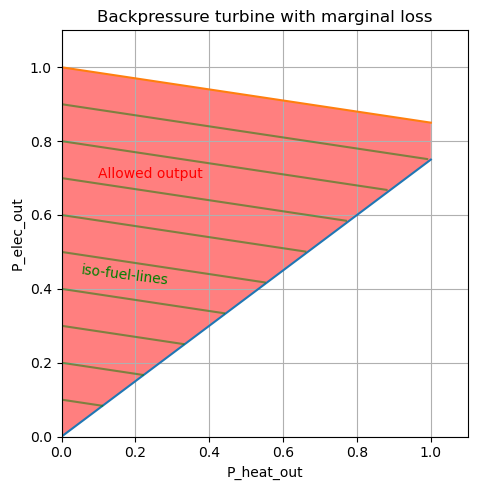

In [180]:
fig, ax = plt.subplots(figsize=(9, 5)) #Creates figure and axes to plot: size 9x5 inches.

t = 0.01 # step size for the range of heat output values
ph = np.arange(0, 1.0001, t) # range of heat output values from 0 to 1 (with a step size of 0.01)

ax.set_xlabel("P_heat_out")
ax.set_ylabel("P_elec_out")
ax.grid(True) # add grid to visualize the plot better
ax.set_title("Backpressure turbine with marginal loss") # title of the plot
ax.set_xlim([0, 1.1]) # set x-axis limits to 0 and 1.1
ax.set_ylim([0, 1.1]) # set y-axis limits to 0 and 1.1
ax.set_aspect('equal') # set the aspect ratio to be equal

ax.plot(ph, c_m * ph) # plot the line for c_m * ph (lower constraint on electricity output as function of heat output)
ax.plot(ph, 1 - c_v * ph) # plot the line for 1 - c_v * ph (upper constraint on electricity output as function of heat output)
ax.text(0.1, 0.7, "Allowed output", color="r") # add text to indicate allowed output area

for i in range(1, 10): # loop to plot iso-fuel-lines (constant fuel consumption levels)
    k = 0.1 * i
    x = np.arange(0, k / (c_m + c_v), t)
    ax.plot(x, k - c_v * x, color="g", alpha=0.5)

ax.text(0.05, 0.41, "iso-fuel-lines", color="g", rotation=-7) # add text to indicate iso-fuel-lines
ax.fill_between(ph, c_m * ph, 1 - c_v * ph, facecolor="r", alpha=0.5) # fill the area between the two lines (allowed output area) with red color an transparency alpha=0.5

fig.tight_layout()
plt.show()          # Muestra la gráfica en el notebook


## Optimisation

In [181]:
network = pypsa.Network()
network.set_snapshots(pd.date_range("2016-01-01 00:00", "2016-01-01 03:00", freq="h")) # set the time range for the network to 4 hours (from 00:00 to 03:00) with hourly frequency

network.add("Bus", "0", carrier="AC")
network.add("Bus", "0 gas", carrier="gas")

network.add("Carrier", "wind")
network.add("Carrier", "gas", co2_emissions=0.2)

network.add("GlobalConstraint", "co2_limit", sense="<=", constant=0.0)

network.add(
    "Generator",
    "wind turbine",
    bus="0",
    carrier="wind",
    p_nom_extendable=True,
    p_max_pu=[0.0, 0.2, 0.7, 0.4],
    capital_cost=1000,
)

network.add("Load", "load", bus="0", p_set=5.0)

network.add(
    "Link",
    "P2G",
    bus0="0",
    bus1="0 gas",
    efficiency=0.6,
    capital_cost=1000,
    p_nom_extendable=True,
)

network.add(
    "Link",
    "generator",
    bus0="0 gas",
    bus1="0",
    efficiency=0.468,
    capital_cost=400,
    p_nom_extendable=True,
)

network.add("Store", "gas depot", bus="0 gas", e_cyclic=True, e_nom_extendable=True)

Index(['gas depot'], dtype='object')

Add heat sector

In [182]:
network.add("Bus", "0 heat", carrier="heat")

network.add("Carrier", "heat")

network.add("Load", "heat load", bus="0 heat", p_set=10.0)

network.add(
    "Link",
    "boiler",
    bus0="0 gas",
    bus1="0 heat",
    efficiency=0.9,
    capital_cost=300,
    p_nom_extendable=True,
)

network.add("Store", "water tank", bus="0 heat", e_cyclic=True, e_nom_extendable=True)

Index(['water tank'], dtype='object')

Add CHP constraints

In [183]:
# Guarantees ISO fuel lines, i.e. fuel consumption p_b0 + p_g0 = constant along p_g1 + c_v p_b1 = constant
# Establece la eficiencia de la caldera ("boiler") en función de la eficiencia del generador y el coeficiente de pérdida marginal (c_v).
network.links.at["boiler", "efficiency"] = (
    network.links.at["generator", "efficiency"] / c_v
)

# Convierte la eficiencia de la caldera a un valor flotante para usarlo en cálculos posteriores.
boiler_eff = float(network.links.at["boiler", "efficiency"])
# Convierte la eficiencia del generador a un valor flotante para usarlo en cálculos posteriores.
generator_eff = float(network.links.at["generator", "efficiency"])
# Crea un modelo de optimización para la red energética.
model = network.optimize.create_model()

# Recupera las variables del modelo que representan los flujos de potencia a través de los enlaces.
link_p = model.variables["Link-p"]
# Recupera las variables del modelo que representan las capacidades nominales de los enlaces.
link_p_nom = model.variables["Link-p_nom"]

# Guarantees heat output and electric output nominal powers are proportional
# Añade una restricción al modelo para asegurar que la potencia nominal del generador (electricidad)
# sea proporcional a la potencia nominal de la caldera (calor) en función de sus eficiencias y la relación `nom_r`definida al inicio. 
model.add_constraints(
    generator_eff * nom_r * link_p_nom.loc["generator"]
    - boiler_eff * link_p_nom.loc["boiler"]
    == 0,
    name="heat-power output proportionality",
)

# Guarantees c_m p_b1  \leq p_g1
# Garantiza que el calor generado por la caldera (boiler) escalado por el límite de presión de retorno (c_m)
# y su eficiencia no exceda la electricidad generada por el generador escalada por su eficiencia.
model.add_constraints(
    link_p.loc[:, "boiler"] * c_m * boiler_eff
    - link_p.loc[:, "generator"] * generator_eff
    <= 0,
    name="backpressure",
)

# Guarantees p_g1 + c_v p_b1 \leq p_g1_nom
# Garantiza que la suma de la electricidad generada (generador) y el calor generado (caldera),
# escalado por el coeficiente de pérdida marginal (c_v), no exceda la capacidad nominal del generador.
model.add_constraints(
    link_p.loc[:, "boiler"] + link_p.loc[:, "generator"] - link_p_nom.loc["generator"]
    <= 0,
    name="top_iso_fuel_line",
)

# Resuelve el modelo de optimización para encontrar la solución óptima.
network.optimize.solve_model()

Index(['P2G'], dtype='object', name='Link')
Index(['0'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 38 primals, 83 duals
Objective: 1.62e+05
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, backpressure, top_iso_fuel_line were not assigned to the network.


('ok', 'optimal')

In [184]:
network.objective

162253.99956169186

## Inspection

In [185]:
network.loads_t.p

Load,load,heat load
snapshot,,
2016-01-01 00:00:00,5.0,10.0
2016-01-01 01:00:00,5.0,10.0
2016-01-01 02:00:00,5.0,10.0
2016-01-01 03:00:00,5.0,10.0


In [186]:
network.links.p_nom_opt

Link
P2G          58.648915
generator    28.490028
boiler        4.273504
Name: p_nom_opt, dtype: float64

In [187]:
# CHP is dimensioned by the heat demand met in three hours when no wind
4 * 10.0 / 3 / network.links.at["boiler", "efficiency"]

4.273504273504273

In [188]:
# elec is set by the heat demand
28.490028 * 0.15

4.2735042

In [189]:
network.links_t.p0

Link,P2G,generator,boiler
snapshot,,,
2016-01-01 00:00:00,5.000000,21.367521,4.273504
2016-01-01 01:00:00,23.185404,21.367521,4.273504
2016-01-01 02:00:00,58.648915,-0.000000,-0.000000
2016-01-01 03:00:00,41.370809,21.367521,4.273504


In [190]:
network.links_t.p1

Link,P2G,generator,boiler
snapshot,,,
2016-01-01 00:00:00,-3.000000,-10.0,-13.333333
2016-01-01 01:00:00,-13.911243,-10.0,-13.333333
2016-01-01 02:00:00,-35.189349,0.0,0.000000
2016-01-01 03:00:00,-24.822485,-10.0,-13.333333


In [191]:
pd.DataFrame({attr: network.stores_t[attr]["gas depot"] for attr in ["p", "e"]})

,p,e
snapshot,,
2016-01-01 00:00:00,22.641026,11.729783
2016-01-01 01:00:00,11.729783,-0.000000
2016-01-01 02:00:00,-35.189349,35.189349
2016-01-01 03:00:00,0.818540,34.370809


In [192]:
pd.DataFrame({attr: network.stores_t[attr]["water tank"] for attr in ["p", "e"]})

,p,e
snapshot,,
2016-01-01 00:00:00,-3.333333,6.666667
2016-01-01 01:00:00,-3.333333,10.000000
2016-01-01 02:00:00,10.000000,-0.000000
2016-01-01 03:00:00,-3.333333,3.333333


In [193]:
pd.DataFrame({attr: network.links_t[attr]["boiler"] for attr in ["p0", "p1"]})

,p0,p1
snapshot,,
2016-01-01 00:00:00,4.273504,-13.333333
2016-01-01 01:00:00,4.273504,-13.333333
2016-01-01 02:00:00,-0.000000,0.000000
2016-01-01 03:00:00,4.273504,-13.333333


In [194]:
network.stores.loc["gas depot"]

bus                            0 gas
type                                
carrier                          gas
e_nom                            0.0
e_nom_mod                        0.0
e_nom_extendable                True
e_nom_min                        0.0
e_nom_max                        inf
e_min_pu                         0.0
e_max_pu                         1.0
e_initial                        0.0
e_initial_per_period           False
e_cyclic                        True
e_cyclic_per_period             True
p_set                            0.0
q_set                            0.0
sign                             1.0
marginal_cost                    0.0
marginal_cost_quadratic          0.0
marginal_cost_storage            0.0
capital_cost                     0.0
standing_loss                    0.0
active                          True
build_year                         0
lifetime                         inf
e_nom_opt                  35.189349
Name: gas depot, dtype: object

In [195]:
network.generators.loc["wind turbine"]

bus                                0
control                           PQ
type                                
p_nom                            0.0
p_nom_mod                        0.0
p_nom_extendable                True
p_nom_min                        0.0
p_nom_max                        inf
p_min_pu                         0.0
p_max_pu                         1.0
p_set                            0.0
e_sum_min                       -inf
e_sum_max                        inf
q_set                            0.0
sign                             1.0
carrier                         wind
marginal_cost                    0.0
marginal_cost_quadratic          0.0
active                          True
build_year                         0
lifetime                         inf
capital_cost                  1000.0
efficiency                       1.0
committable                    False
start_up_cost                    0.0
shut_down_cost                   0.0
stand_by_cost                    0.0
m

In [196]:
network.links.p_nom_opt

Link
P2G          58.648915
generator    28.490028
boiler        4.273504
Name: p_nom_opt, dtype: float64

Calculate the overall efficiency of the CHP

In [197]:
eta_elec = network.links.at["generator", "efficiency"]

r = 1 / c_m

# P_h = r*P_e
(1 + r) / ((1 / eta_elec) * (1 + c_v * r))

0.9099999999999999